[*********************100%***********************]  2 of 2 completed


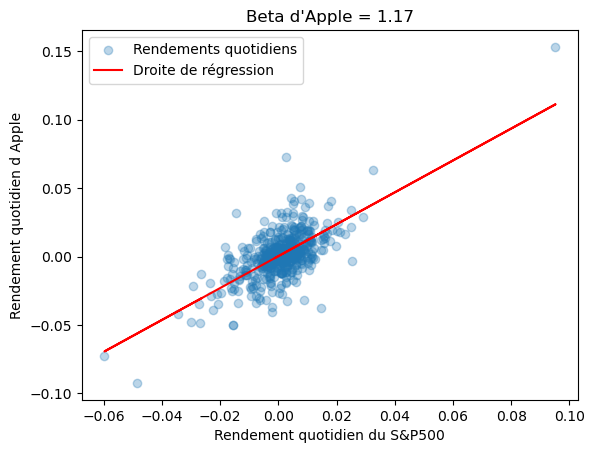

Rendement attendu d'Apple selon le MEDAF : 19.98%


In [20]:
import yfinance as yf
import numpy as np 
import pandas as pd
F=yf.download(['^GSPC','AAPL'],period='2y')['Close']#les prix de clotures d apple et de S&P500 de 2ans
Rd=F.pct_change().dropna()
matrix=np.cov(Rd['AAPL'],Rd['^GSPC'])
cov=matrix[0][1]
var=matrix[1][1]
beta=cov/var
from scipy import stats
RL=stats.linregress(Rd['^GSPC'], Rd['AAPL']) 
beta_reg=RL.slope
alpha=RL.intercept
r=RL.rvalue
r2=RL.rvalue**2
pvalue=RL.pvalue
e=RL.stderr
import matplotlib.pyplot as plt
x=Rd['^GSPC']
plt.scatter(x,Rd['AAPL'], alpha=0.3, label="Rendements quotidiens")
y=beta_reg*x+alpha
plt.plot(x,y,color="red", label="Droite de régression")
plt.xlabel("Rendement quotidien du S&P500")       
plt.ylabel("Rendement quotidien d Apple")       
plt.title(f"Beta d'Apple = {beta_reg:.2f}")
plt.legend()
plt.show()
Rf = 0.03        # taux sans risque annuel (approximation)
Rm = Rd['^GSPC'].mean() * 252   # rendement annualisé du marché
E_RAAPL = Rf + beta_reg * (Rm - Rf)
print(f"Rendement attendu d'Apple selon le MEDAF : {E_RAAPL:.2%}")
